# Análisis y visualización de señales ECG - BITalino (12 movimientos)

El objetivo  es convertir las señales crudas (ADC) medidas con el BITalino a su unidad física (ECG en mV) y visualizarlas, separando las 4 condiciones fisiológicas medidas, cada una con sus 3 derivaciones (Lead I, Lead II, Lead III):

1. **Reposo**
2. **Hiperventilación**
3. **Hipoventilación**
4. **Actividad aeróbica**

Librería usada para leer y convertir las señales: [`opensignalsreader`](https://github.com/PGomes92/opensignalsreader).

**Importante sobre los archivos `.txt`:** este notebook asume que tus 7 archivos `.txt` de OpenSignals están guardados en **Google Drive, en la misma carpeta donde está este notebook**. La celda siguiente monta tu Google Drive (si usas Google Colab) y ubica automáticamente esa carpeta.

Si en cambio estás corriendo este notebook en Jupyter local (no Colab) con los `.txt` en la misma carpeta del `.ipynb`, puedes saltarte la celda de montaje de Drive: la carpeta de datos por defecto (`.`) ya apunta a la carpeta actual.

In [ ]:
# Instalar dependencias (solo la primera vez que corras el notebook)
!pip install -q opensignalsreader matplotlib numpy

## 1. Montar Google Drive y ubicar la carpeta de datos

En **Google Colab**, ejecuta la siguiente celda: montará tu Drive y buscará automáticamente la carpeta donde está este notebook (usando el path de Drive). Colocar los 7 archivos `.txt` en esa misma carpeta.

Asegurarse de que los `.txt` estén junto al `.ipynb` y deja `CARPETA_DATOS = "."`.

In [ ]:
import os

# Carpeta de datos por defecto: la misma carpeta donde está el notebook
CARPETA_DATOS = "."

try:
    # Esto solo funciona dentro de Google Colab
    from google.colab import drive
    drive.mount('/content/drive')

    # --------------------------------------------------------------
    CARPETA_DATOS = "/content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB4_ECG"

    print(f"Google Drive montado. Carpeta de datos configurada en: {CARPETA_DATOS}")

except ImportError:
    print("No se detectó Google Colab. Se usará la carpeta local del notebook (.)")

print("Contenido de la carpeta de datos:")
if os.path.isdir(CARPETA_DATOS):
    print(os.listdir(CARPETA_DATOS))
else:
    print(f"  [!] La carpeta '{CARPETA_DATOS}' todavía no existe o la ruta es incorrecta.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado. Carpeta de datos configurada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB4_ECG
Contenido de la carpeta de datos:
['Reposo DI.txt', 'Reposo DI.h5', 'Reposo DII.txt', 'Reposo DII.h5', 'Reposo DIII.txt', 'Reposo DIII.h5', 'Hiperventilacion DIII.txt', 'Hiperventilacion DIII.h5', 'Hiperventilacion DII.txt', 'Hiperventilacion DII.h5', 'Hiperventilacion DI.h5', 'Hiperventilacion DI.txt', 'Hipoventilacion DI.txt', 'Hipoventilacion DI.h5', 'Hipoventilacion DII.h5', 'Hipoventilacion DII.txt', 'Hipoventilacion DIII.txt', 'Hipoventilacion DIII.h5', 'act DIII.txt', 'act DIII.h5', 'act DII.txt', 'act DII.h5', 'act DI.txt', 'act DI.h5', 'figuras_bitalino', 'analisis_bitalino_ECG.ipynb']


## 2. Configuración de los 7 archivos

Reemplaza los nombres referenciales por los nombres reales de tus `.txt` una vez que los subas a Drive. Se mantienen agrupados según tu diseño experimental.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from opensignalsreader import OpenSignalsReader

%matplotlib inline

# Nombres de archivo (referenciales por ahora). Reemplázalos por los reales.
ARCHIVOS = {
    "Reposo": {
        "Reposo DI.txt",
        "Reposo DII.txt",
        "Reposo DIII.txt",
    },
    "Hiperventilación": {
        "Hiperventilacion DI.txt",
        "Hiperventilacion DII.txt",
        "Hiperventilacion DIII.txt",
    },
    "Hipoventilación": {
        "Hipoventilacion DI.txt",
        "Hipoventilacion DII.txt",
        "Hipoventilacion DIII.txt",
    },
    "Actividad aeróbica": {
        "act DI.txt",
        "act DII.txt",
        "act DIII.txt",
    },

}

# Único sensor usado en las mediciones: ECG
CANAL = "ECG"
UNIDAD = "mV"

# Carpeta donde se guardarán las figuras generadas (dentro de la misma carpeta de datos)
CARPETA_SALIDA = os.path.join(CARPETA_DATOS, "figuras_bitalino")

# Si True, se grafica también la señal cruda (ADC) superpuesta
MOSTRAR_CRUDO = False

#
COLORES = {
    "Reposo": "tab:green",
    "Hiperventilación": "tab:orange",
    "Hipoventilación": "tab:purple",
    "Actividad aeróbica": "tab:red",
}

ZORDERS = {
    "Reposo": 4,
    "Hiperventilación": 3,
    "Hipoventilación": 2,
    "Actividad aeróbica": 1,
}

## Instalacion de open signals

In [ ]:
pip install opensignalsreader

## 3. Funciones de carga y graficado

In [ ]:
def cargar_senal(ruta_archivo, canal):
    """
    Carga un archivo OpenSignals/BITalino y devuelve:
        t        -> vector de tiempo (s)
        senal    -> señal ECG convertida a mV
        senal_cr -> señal cruda (ADC)
        fs       -> frecuencia de muestreo (Hz)

    Si el archivo aún no existe, devuelve None para no interrumpir el
    resto del notebook mientras vas agregando tus .txt uno por uno.
    """
    if not os.path.isfile(ruta_archivo):
        print(f"  [!] No se encontró el archivo: {ruta_archivo} (aún no agregado)")
        return None

    acq = OpenSignalsReader(ruta_archivo)

    senal = acq.signal(canal)      # señal convertida a mV
    senal_cr = acq.raw(canal)      # señal cruda (valor ADC)
    fs = acq.sampling_rate         # frecuencia de muestreo (Hz)

    t = np.arange(len(senal)) / fs

    return t, senal, senal_cr, fs

In [ ]:
def graficar_grupo(nombre_grupo, dict_leads, canal, carpeta_datos,
                    mostrar_crudo=False, carpeta_salida=None):
    """
    Grafica las 3 derivaciones (Lead I, II, III) de una misma condición
    en una sola figura, un subplot por derivación.
    """
    leads = list(dict_leads.keys())
    n = len(leads)
    fig, ejes = plt.subplots(n, 1, figsize=(10, 3 * n), sharex=False)

    if n == 1:
        ejes = [ejes]

    fig.suptitle(f"{nombre_grupo} - ECG", fontsize=14, fontweight="bold")

    for ax, lead in zip(ejes, leads):
        nombre_archivo = dict_leads[lead]
        ruta = os.path.join(carpeta_datos, nombre_archivo)
        resultado = cargar_senal(ruta, canal)

        if resultado is None:
            ax.set_title(f"{lead} - {nombre_archivo} (pendiente de agregar)")
            ax.text(0.5, 0.5, "Archivo no encontrado", ha="center", va="center",
                    transform=ax.transAxes, color="gray")
            continue

        t, senal, senal_cr, fs = resultado

        ax.plot(t, senal, linewidth=0.8)
        ax.set_title(lead)
        ax.set_xlabel("Tiempo (s)")
        ax.set_ylabel(f"ECG ({UNIDAD})")
        ax.set_xlim(0, 15) # Show first 15 seconds

        ax.grid(alpha=0.3)

        if mostrar_crudo:
            ax2 = ax.twinx()
            ax2.plot(t, senal_cr, color="orange", alpha=0.4, linewidth=0.6)
            ax2.set_ylabel("Valor crudo (ADC)", color="orange")

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if carpeta_salida:
        os.makedirs(carpeta_salida, exist_ok=True)
        nombre_fig = nombre_grupo.lower().replace(" ", "_") + ".png"
        ruta_fig = os.path.join(carpeta_salida, nombre_fig)
        fig.savefig(ruta_fig, dpi=150)
        print(f"  -> Figura guardada en: {ruta_fig}")

    return fig

In [ ]:
import re # Ensure re is imported for regex operations

def graficar_comparacion_por_lead(archivos_dict, lead, canal, carpeta_datos,
                                   colores, zorders, carpeta_salida=None):
    """
    Genera una figura comparando las 4 condiciones (Reposo, Hiperventilación,
    Hipoventilación, Actividad aeróbica) para UNA sola derivación dada
    (por ejemplo, solo 'Lead I'), superponiendo las señales.
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    # Mapping from 'Lead I' to 'DI' for file identification in processed_dict_leads
    lead_map_to_id = {'Lead I': 'DI', 'Lead II': 'DII', 'Lead III': 'DIII'}
    target_lead_id = lead_map_to_id.get(lead)

    if not target_lead_id:
        print(f"  [!] Derivación '{lead}' no válida para comparación.")
        plt.close(fig) # Close the empty figure
        return fig

    has_data_to_plot = False # Flag to check if any data was plotted

    for nombre_grupo, list_of_filenames_in_group in archivos_dict.items():
        # Re-process filenames to get lead_identifier -> filename mapping for the current group
        processed_dict_leads = {}
        for filename in list_of_filenames_in_group:
            match = re.search(r'(D[I]+)\.txt', filename, re.IGNORECASE)
            if match:
                lead_identifier = match.group(1).upper()
                processed_dict_leads[lead_identifier] = filename
            else:
                # Fallback for filenames without a clear lead identifier
                # Use the filename without extension as the key (converted to uppercase)
                processed_dict_leads[filename.replace('.txt', '').upper()] = filename

        if target_lead_id not in processed_dict_leads:
            print(f"  [!] Archivo para {lead} (ID: {target_lead_id}) no encontrado en el grupo {nombre_grupo}.")
            continue

        nombre_archivo = processed_dict_leads[target_lead_id]
        ruta = os.path.join(carpeta_datos, nombre_archivo)
        resultado = cargar_senal(ruta, canal)

        if resultado is None:
            print(f"  [!] No se pudo cargar la señal para {nombre_archivo} en el grupo {nombre_grupo}.")
            continue

        t, senal, senal_cr, fs = resultado

        # Apply filtering for comparison, consistent with graficar_grupo_filtrado
        senal_filtrada = filtrar_ecg(senal, fs, notch_freq=49.5)

        ax.plot(t, senal_filtrada, label=nombre_grupo,
                color=colores.get(nombre_grupo), alpha=0.7, linewidth=0.8,
                zorder=zorders.get(nombre_grupo))
        has_data_to_plot = True

    ax.set_title(f"Comparación general - ECG Filtrado ({lead})")
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel(f"ECG ({UNIDAD})")
    # Only add legend if there was data plotted
    if has_data_to_plot:
        ax.legend(fontsize=9, loc="upper right")
    ax.grid(alpha=0.3)
    plt.tight_layout()

    if carpeta_salida and has_data_to_plot:
        os.makedirs(carpeta_salida, exist_ok=True)
        nombre_fig = f"comparacion_general_filtrada_{lead.lower().replace(' ', '_')}.png"
        ruta_fig = os.path.join(carpeta_salida, nombre_fig)
        fig.savefig(ruta_fig, dpi=150)
        print(f"  -> Figura de comparación general filtrada guardada en: {ruta_fig}")
    elif not has_data_to_plot:
        print(f"  [!] No se graficó ninguna señal para la derivación {lead}.")
        plt.close(fig) # Close the empty figure

    return fig

## 4. Funciones del filtro ECG
1. Filtro pasa-altos (0.5 Hz) — para eliminar el baseline wander (deriva de la línea base), causado por la respiración, el movimiento de electrodos o el sudor.
2. Filtro pasa-bajos (40 Hz para monitoreo) — para eliminar ruido de alta frecuencia, principalmente interferencia muscular (EMG) captada por los mismos electrodos.
3. Filtro notch (rechazo de banda) de 60 Hz — para eliminar la interferencia de la red eléctrica con un factor de calidad de 30, para que ancho de banda de atenuación sea corta (2 Hz)



In [ ]:
from scipy.signal import butter, filtfilt, iirnotch

def filtrar_ecg(senal, fs, low=0.5, high=40, notch_freq=60, notch_q=30):
    """
    Filtra una señal ECG:
    - Pasa-banda Butterworth (low-high Hz) para quitar baseline wander y ruido de alta frecuencia.
    - Notch en notch_freq Hz para quitar interferencia de línea eléctrica.
    """
    nyq = fs / 2

    # Pasa-banda
    b, a = butter(4, [low / nyq, high / nyq], btype="band")
    senal_filtrada = filtfilt(b, a, senal)

    # Notch (línea eléctrica)
    b_notch, a_notch = iirnotch(notch_freq / nyq, notch_q)
    senal_filtrada = filtfilt(b_notch, a_notch, senal_filtrada)

    return senal_filtrada

In [ ]:
def graficar_senal_filtrada(t, senal_original, senal_filtrada, titulo, unidad="mV",
                             carpeta_salida=None, nombre_fig=None):
    """
    Grafica la señal original (de fondo, gris) y la señal filtrada (al frente)
    en una misma figura para comparar el efecto del filtro.
    """
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t, senal_original, label="Original", color="gray", alpha=0.5, linewidth=0.7)
    ax.plot(t, senal_filtrada, label="Filtrada", color="tab:blue", linewidth=0.9)
    ax.set_title(titulo)
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel(f"ECG ({unidad})")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 15)   # <-- solo muestra los primeros 15 segundos
    #ax.set_xlim(t[-1] - 15, t[-1])
    plt.tight_layout()

    if carpeta_salida and nombre_fig:
        os.makedirs(carpeta_salida, exist_ok=True)
        ruta_fig = os.path.join(carpeta_salida, nombre_fig)
        fig.savefig(ruta_fig, dpi=150)
        print(f"  -> Figura guardada en: {ruta_fig}")

    return fig

In [ ]:
def graficar_grupo_filtrado(nombre_grupo, dict_leads, canal, carpeta_datos,
                            low_band=0.5, high_band=40, notch_freq=60, notch_q=30,
                            carpeta_salida=None):
    """
    Grafica las 3 derivaciones (Lead I, II, III) de una misma condición
    en una sola figura, un subplot por derivación, usando las señales filtradas.
    """
    leads = list(dict_leads.keys())
    n = len(leads)
    fig, ejes = plt.subplots(n, 1, figsize=(10, 3 * n), sharex=False)

    if n == 1:
        ejes = [ejes]

    fig.suptitle(f"{nombre_grupo} - ECG Filtrado vs Original", fontsize=14, fontweight="bold")

    for ax, lead in zip(ejes, leads):
        nombre_archivo = dict_leads[lead]
        ruta = os.path.join(carpeta_datos, nombre_archivo)
        resultado = cargar_senal(ruta, canal)

        if resultado is None:
            ax.set_title(f"{lead} - {nombre_archivo} (pendiente de agregar)")
            ax.text(0.5, 0.5, "Archivo no encontrado", ha="center", va="center",
                    transform=ax.transAxes, color="gray")
            continue

        t, senal, senal_cr, fs = resultado
        senal_filtrada = filtrar_ecg(senal, fs, low=low_band, high=high_band,
                                     notch_freq=notch_freq, notch_q=notch_q)

        ax.plot(t, senal, label="Original", color="gray", alpha=0.7, linewidth=0.7) # Plot original signal
        ax.plot(t, senal_filtrada, label="Filtrada", color="tab:blue", linewidth=0.9) # Plot filtered signal
        ax.set_title(lead)
        ax.set_xlabel("Tiempo (s)")
        ax.set_ylabel(f"ECG ({UNIDAD})")
        ax.legend(fontsize=9) # Add legend
        ax.grid(alpha=0.3)
        ax.set_xlim(0, 15) # Show first 15 seconds

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if carpeta_salida:
        os.makedirs(carpeta_salida, exist_ok=True)
        nombre_fig = f"{nombre_grupo.lower().replace(' ', '_')}_filtrado_grupo.png"
        ruta_fig = os.path.join(carpeta_salida, nombre_fig)
        fig.savefig(ruta_fig, dpi=150)
        print(f"  -> Figura de grupo filtrada guardada en: {ruta_fig}")

    return fig

## 5. Funciones de análisis en el dominio de la frecuencia (FFT)

In [ ]:
def calcular_fft_db(senal, fs):
    """
    Calcula la FFT de una señal y devuelve la magnitud en dB.
    """
    N = len(senal)
    yf = np.fft.fft(senal)
    xf = np.fft.fftfreq(N, 1/fs)[:N//2]
    # Evitar log10 de cero o valores muy cercanos a cero
    magnitude_db = 20 * np.log10(np.abs(yf[0:N//2]) + 1e-10) # Añadir un pequeño valor para evitar log(0)
    return xf, magnitude_db

In [ ]:
def graficar_fft_grupo(nombre_grupo, lista_archivos, canal, carpeta_datos, carpeta_salida=None):
    """
    Grafica las FFT en dB de todas las señales de un grupo.
    """
    n = len(lista_archivos)
    fig, ejes = plt.subplots(n, 1, figsize=(10, 3 * n), sharex=False)

    if n == 1:
        ejes = [ejes]

    fig.suptitle(f"{nombre_grupo} - FFT (dB)", fontsize=14, fontweight="bold")

    for ax, nombre_archivo in zip(ejes, lista_archivos):
        ruta = os.path.join(carpeta_datos, nombre_archivo)
        resultado = cargar_senal(ruta, canal)

        if resultado is None:
            ax.set_title(f"{nombre_archivo} (pendiente de agregar)")
            ax.text(0.5, 0.5, "Archivo no encontrado", ha="center", va="center",
                    transform=ax.transAxes, color="gray")
            continue

        t, senal, senal_cr, fs = resultado
        xf, magnitude_db = calcular_fft_db(senal, fs)

        ax.plot(xf, magnitude_db, linewidth=0.8)
        ax.set_title(f"{nombre_archivo} - FFT")
        ax.set_xlabel("Frecuencia (Hz)")
        ax.set_ylabel("Magnitud (dB)")
        ax.grid(alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if carpeta_salida:
        os.makedirs(carpeta_salida, exist_ok=True)
        nombre_fig = nombre_grupo.lower().replace(" ", "_") + "_fft.png"
        ruta_fig = os.path.join(carpeta_salida, nombre_fig)
        fig.savefig(ruta_fig, dpi=150)
        print(f"  -> Figura FFT guardada en: {ruta_fig}")

    return fig

In [ ]:
def graficar_fft_comparacion_general(archivos_dict, canal, carpeta_datos, carpeta_salida=None):
    """
    Genera una figura con las FFT en dB de todos los grupos superpuestas.
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    colores = {"Reposo": "tab:green",
               "Movimiento leve": "tab:blue",
               "Movimiento con fuerza contraria": "tab:red"}

    for nombre_grupo, lista_archivos in archivos_dict.items():
        for nombre_archivo in lista_archivos:
            ruta = os.path.join(carpeta_datos, nombre_archivo)
            resultado = cargar_senal(ruta, canal)
            if resultado is None:
                continue
            t, senal, senal_cr, fs = resultado
            xf, magnitude_db = calcular_fft_db(senal, fs)
            ax.plot(xf, magnitude_db, label=f"{nombre_grupo} - {nombre_archivo}",
                    color=colores.get(nombre_grupo), alpha=0.7, linewidth=0.8)

    ax.set_title("Comparación general - FFT (dB)")
    ax.set_xlabel("Frecuencia (Hz)")
    ax.set_ylabel("Magnitud (dB)")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.3)
    plt.tight_layout()

    if carpeta_salida:
        os.makedirs(carpeta_salida, exist_ok=True)
        ruta_fig = os.path.join(carpeta_salida, "comparacion_general_fft.png")
        fig.savefig(ruta_fig, dpi=150)
        print(f"  -> Figura FFT guardada en: {ruta_fig}")

    return fig

## 6. Ejecutar: graficar los 3 grupos + comparación general


Condición: Reposo (3 derivación(es))
  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB4_ECG/figuras_bitalino/reposo.png


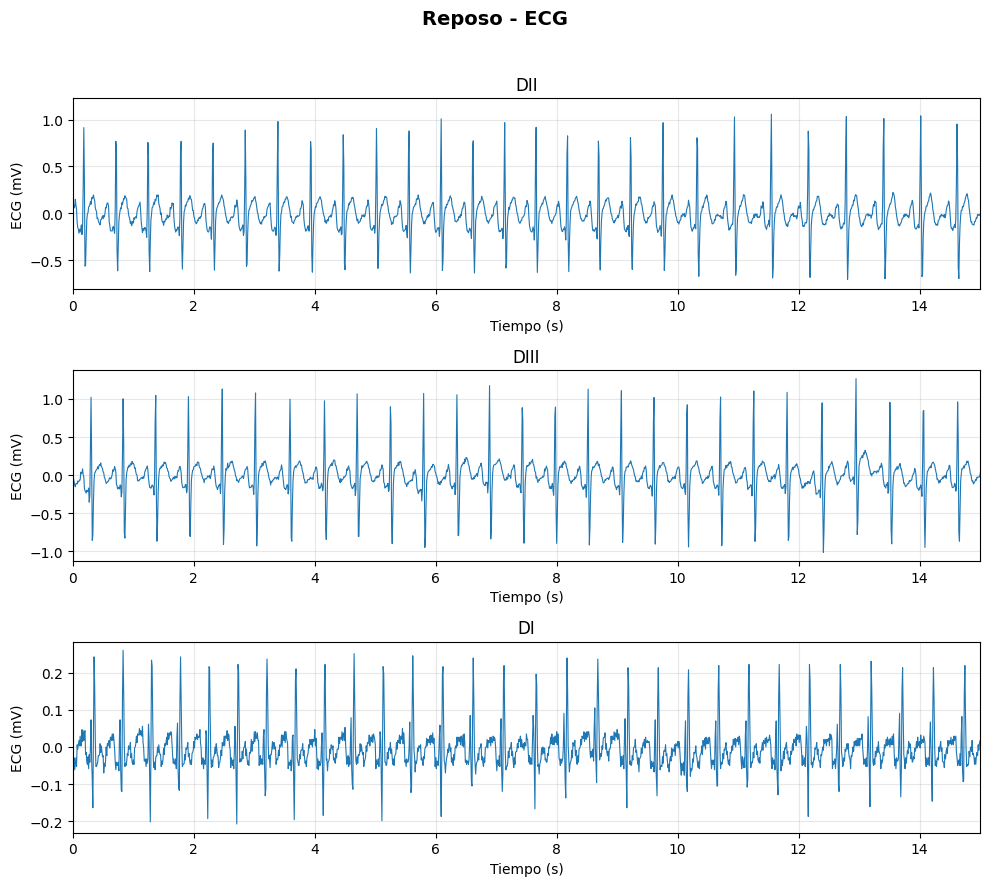


Condición: Hiperventilación (3 derivación(es))
  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB4_ECG/figuras_bitalino/hiperventilación.png


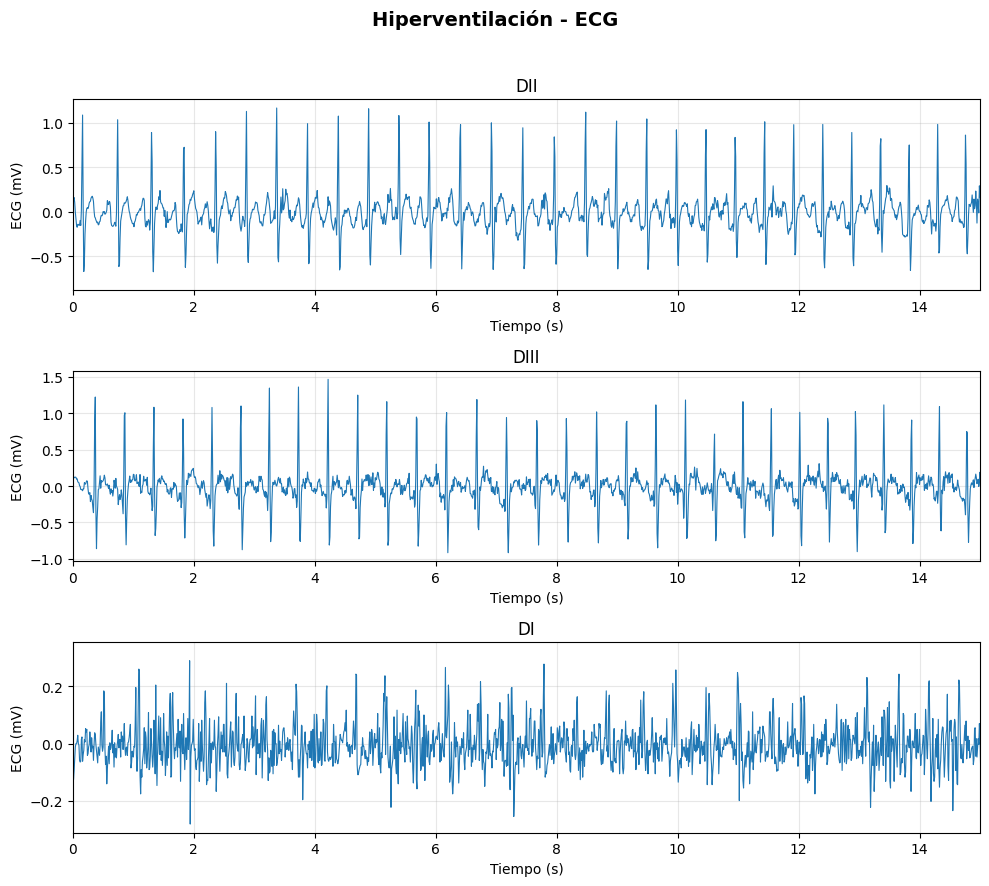


Condición: Hipoventilación (3 derivación(es))
  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB4_ECG/figuras_bitalino/hipoventilación.png


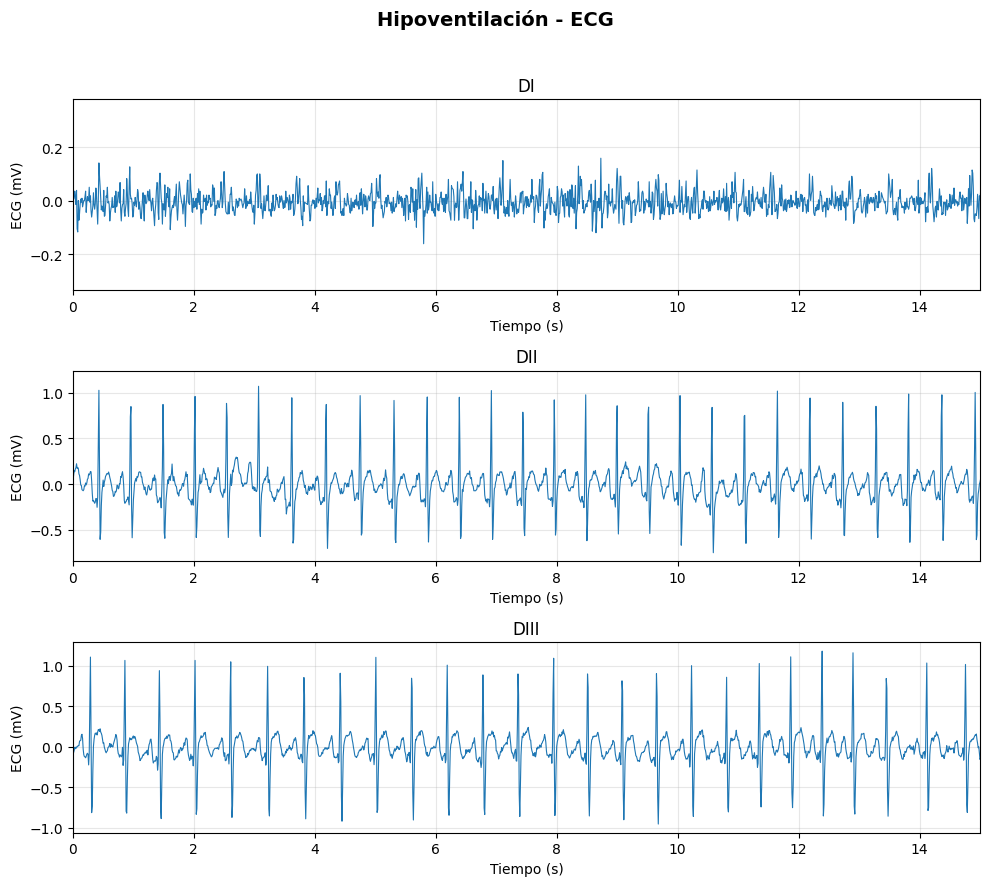


Condición: Actividad aeróbica (3 derivación(es))
  -> Figura guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB4_ECG/figuras_bitalino/actividad_aeróbica.png


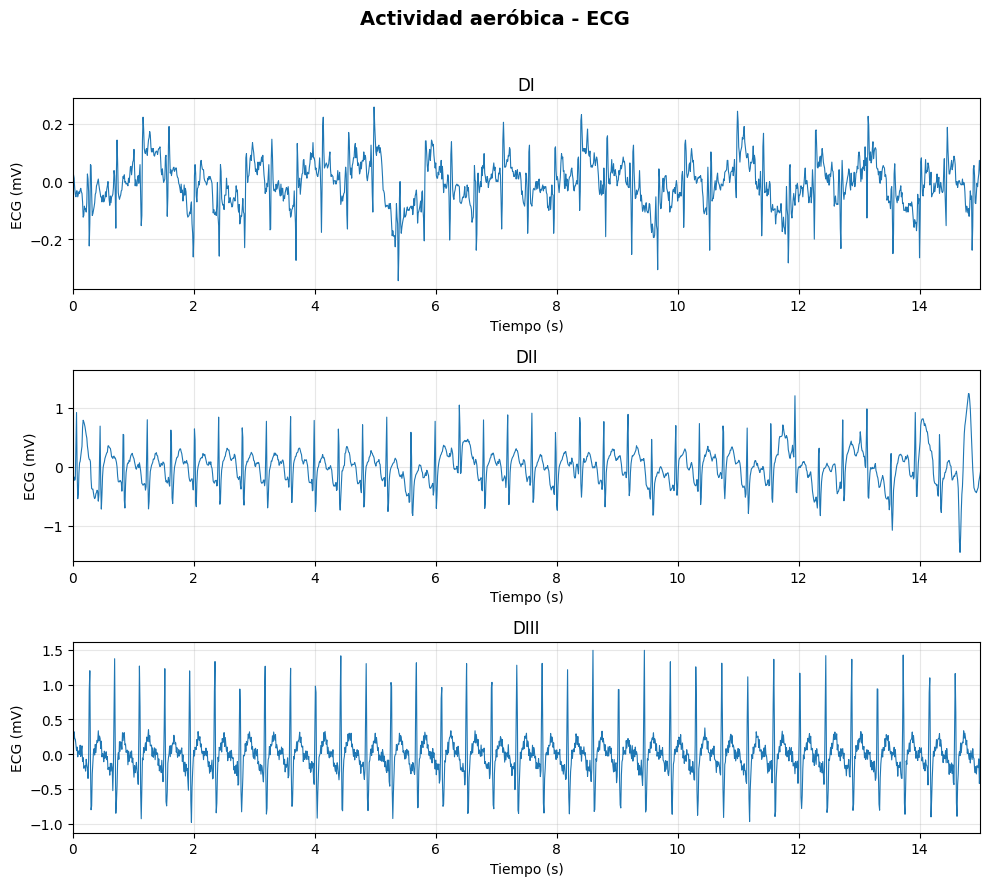

In [ ]:
import re

for nombre_grupo, list_of_filenames in ARCHIVOS.items():
    print(f"\nCondición: {nombre_grupo} ({len(list_of_filenames)} derivación(es))")

    # Transform the set of filenames into a dictionary mapping lead names to filenames
    # This ensures graficar_grupo receives a dictionary as it expects.
    processed_dict_leads = {}
    for filename in list_of_filenames:
        # Attempt to extract lead identifier (e.g., 'DI', 'DII', 'DIII') from filename
        match = re.search(r'(D[I]+)\.txt', filename, re.IGNORECASE)
        if match:
            lead_identifier = match.group(1).upper()
            processed_dict_leads[lead_identifier] = filename
        else:
            # Fallback for filenames without a clear lead identifier
            # Use the filename without extension as the key
            processed_dict_leads[filename.replace('.txt', '')] = filename

    if not processed_dict_leads: # Handle cases where no valid files were processed for a group
        print(f"  [!] No se encontraron archivos válidos para el grupo {nombre_grupo}.")
        plt.close()
        continue

    graficar_grupo(nombre_grupo, processed_dict_leads, CANAL, CARPETA_DATOS,
                   mostrar_crudo=MOSTRAR_CRUDO, carpeta_salida=CARPETA_SALIDA)
    plt.show()


Grupo (FFT): Reposo (3 archivo(s))
  -> Figura FFT guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB4_ECG/figuras_bitalino/reposo_fft.png


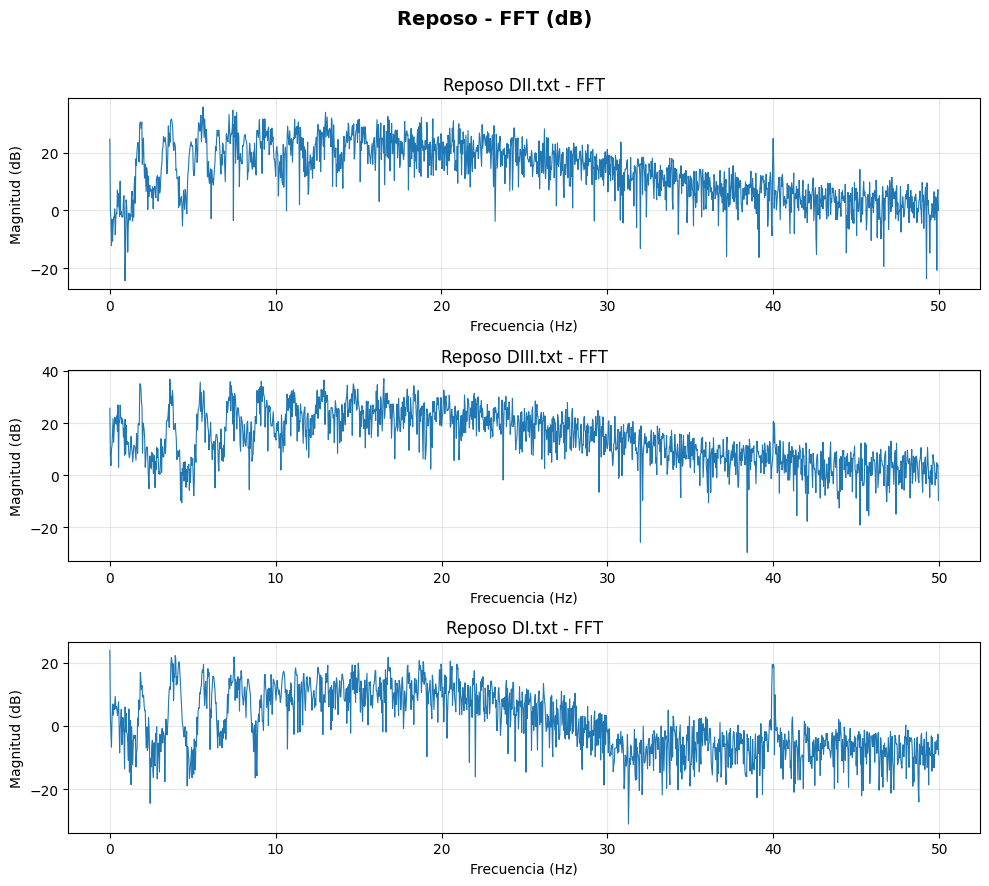


Grupo (FFT): Hiperventilación (3 archivo(s))
  -> Figura FFT guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB4_ECG/figuras_bitalino/hiperventilación_fft.png


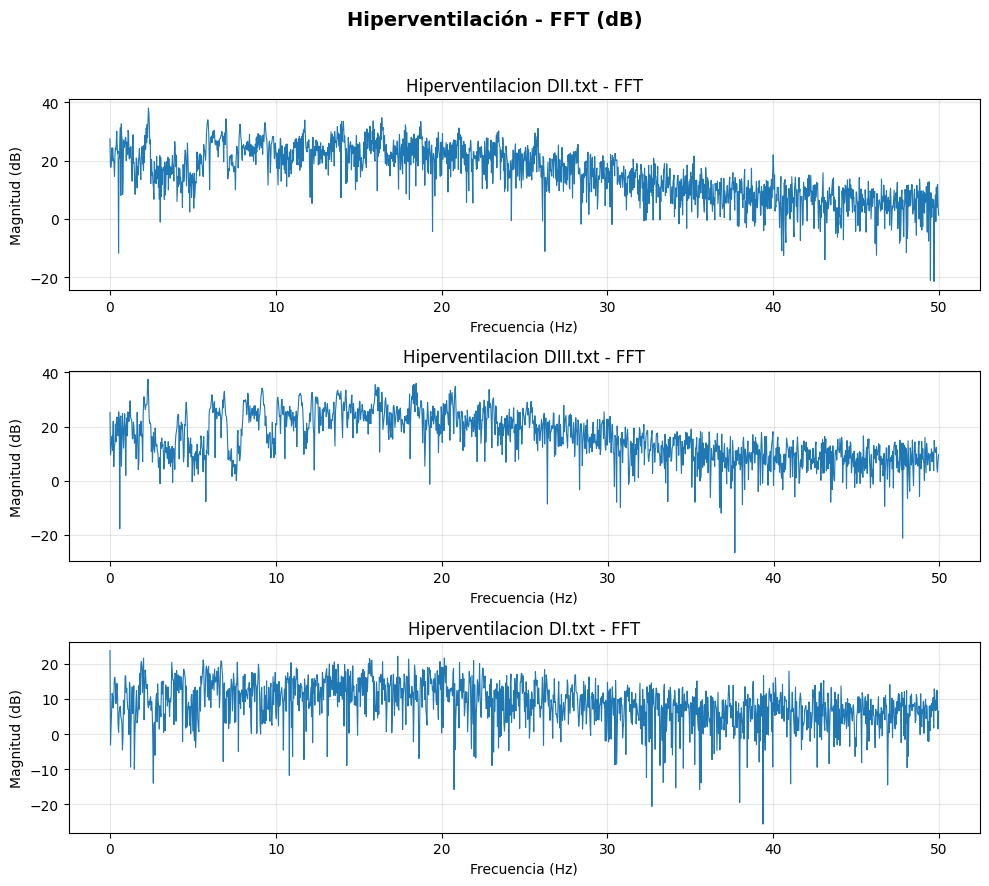


Grupo (FFT): Hipoventilación (3 archivo(s))
  -> Figura FFT guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB4_ECG/figuras_bitalino/hipoventilación_fft.png


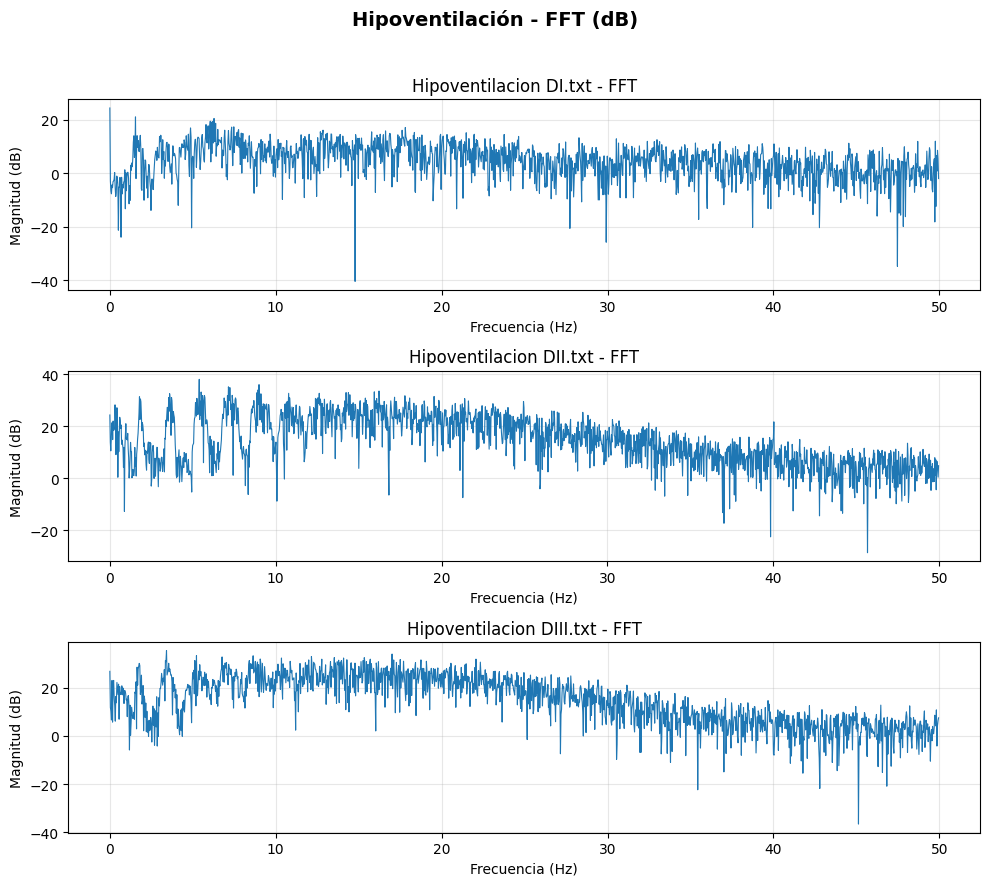


Grupo (FFT): Actividad aeróbica (3 archivo(s))
  -> Figura FFT guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB4_ECG/figuras_bitalino/actividad_aeróbica_fft.png


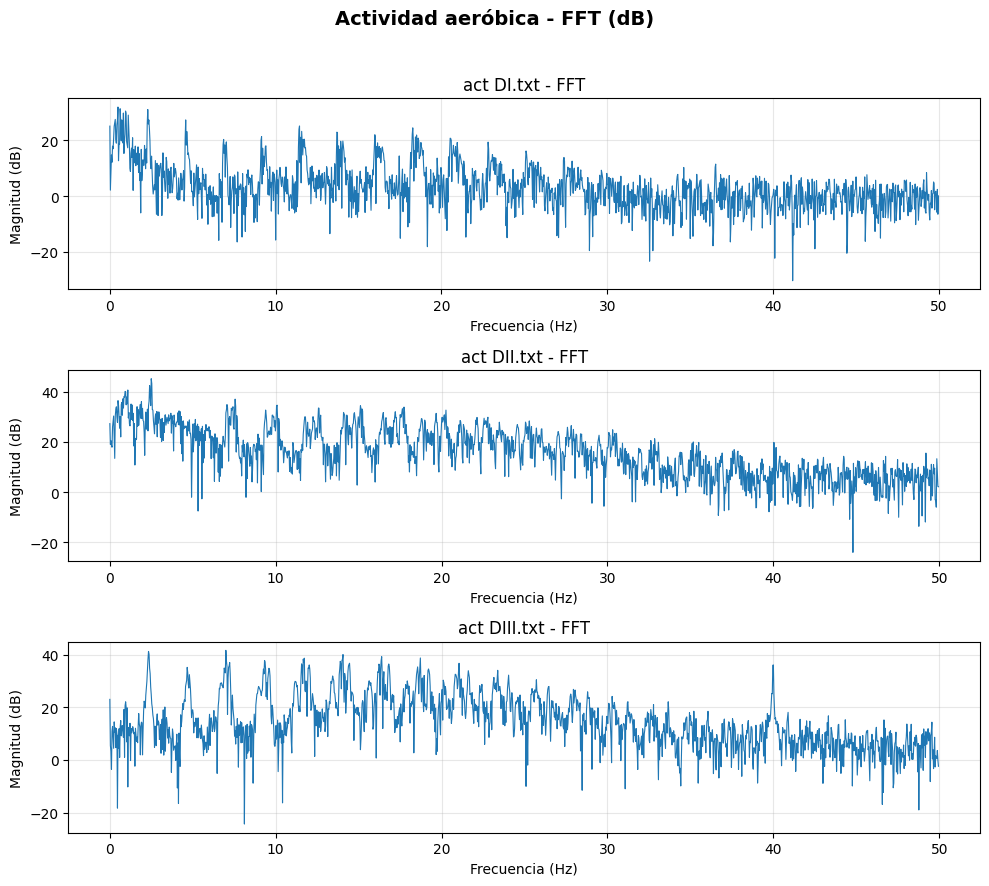

  -> Figura FFT guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB4_ECG/figuras_bitalino/comparacion_general_fft.png


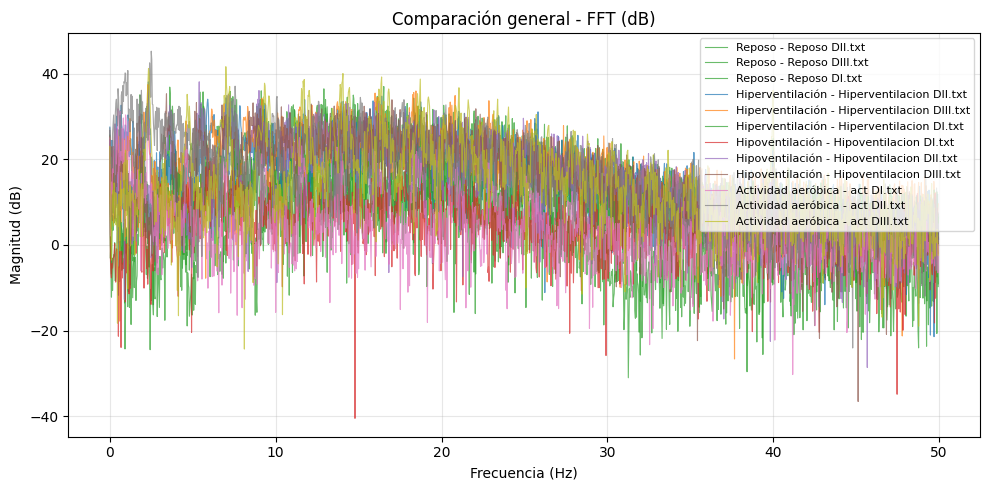

In [ ]:
for nombre_grupo, lista_archivos in ARCHIVOS.items():
    print(f"\nGrupo (FFT): {nombre_grupo} ({len(lista_archivos)} archivo(s))")
    graficar_fft_grupo(nombre_grupo, lista_archivos, CANAL, CARPETA_DATOS, carpeta_salida=CARPETA_SALIDA)
    plt.show()

graficar_fft_comparacion_general(ARCHIVOS, CANAL, CARPETA_DATOS, carpeta_salida=CARPETA_SALIDA)
plt.show()


Condición (filtrada): Reposo (3 derivación(es))
  -> Figura de grupo filtrada guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB4_ECG/figuras_bitalino/reposo_filtrado_grupo.png


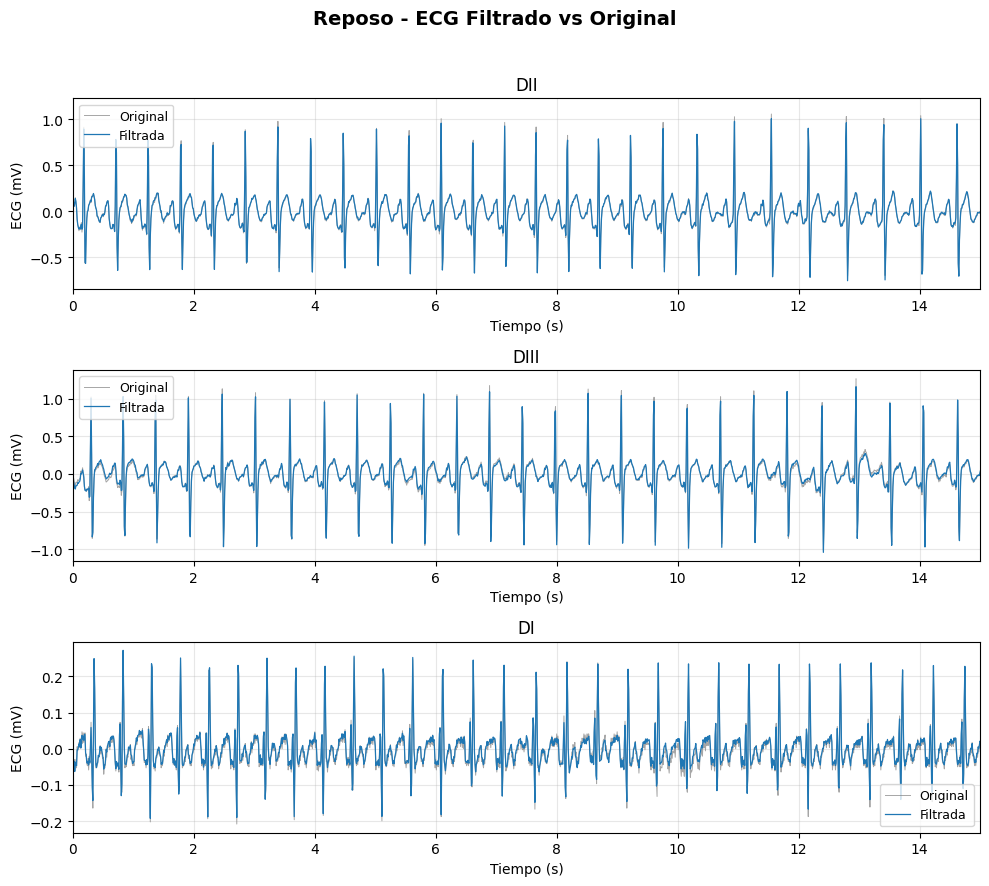


Condición (filtrada): Hiperventilación (3 derivación(es))
  -> Figura de grupo filtrada guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB4_ECG/figuras_bitalino/hiperventilación_filtrado_grupo.png


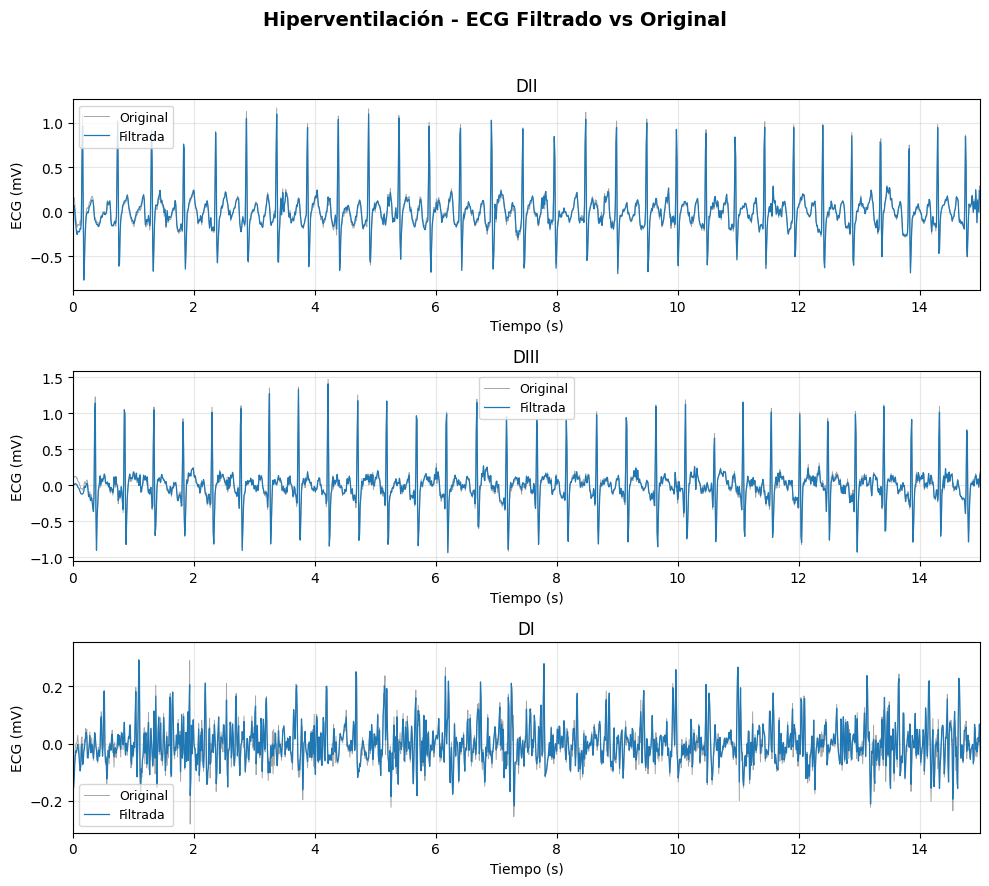


Condición (filtrada): Hipoventilación (3 derivación(es))
  -> Figura de grupo filtrada guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB4_ECG/figuras_bitalino/hipoventilación_filtrado_grupo.png


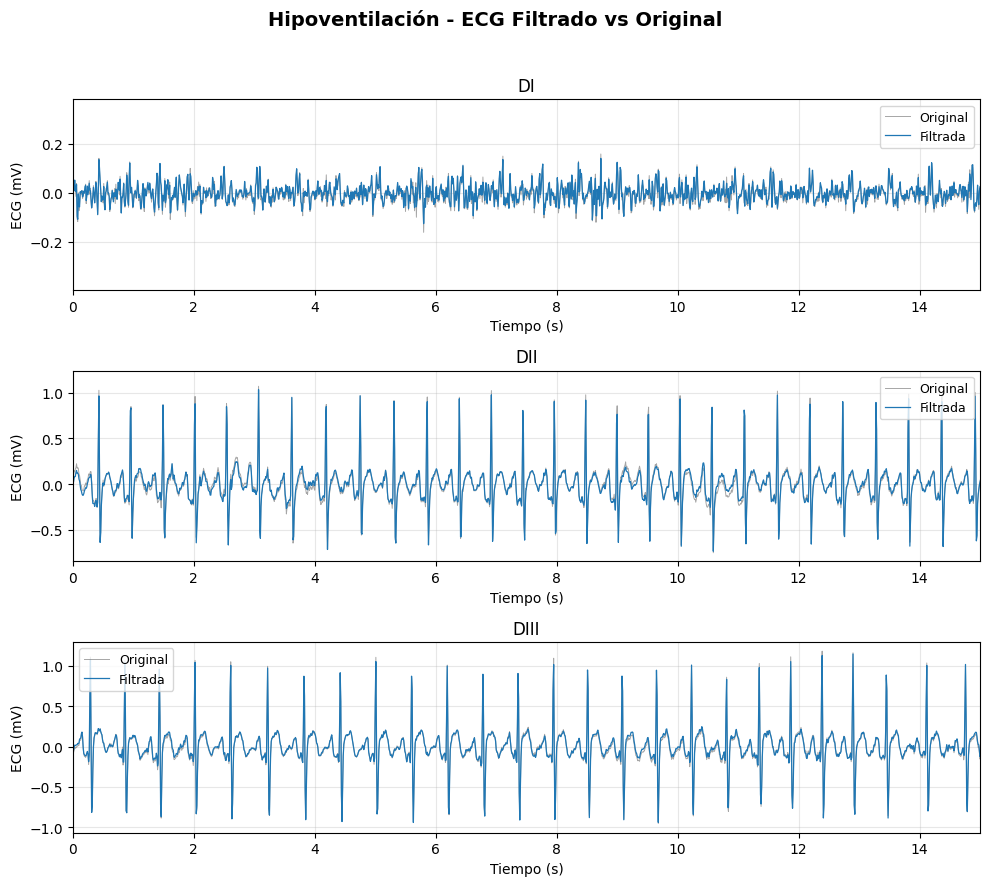


Condición (filtrada): Actividad aeróbica (3 derivación(es))
  -> Figura de grupo filtrada guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB4_ECG/figuras_bitalino/actividad_aeróbica_filtrado_grupo.png


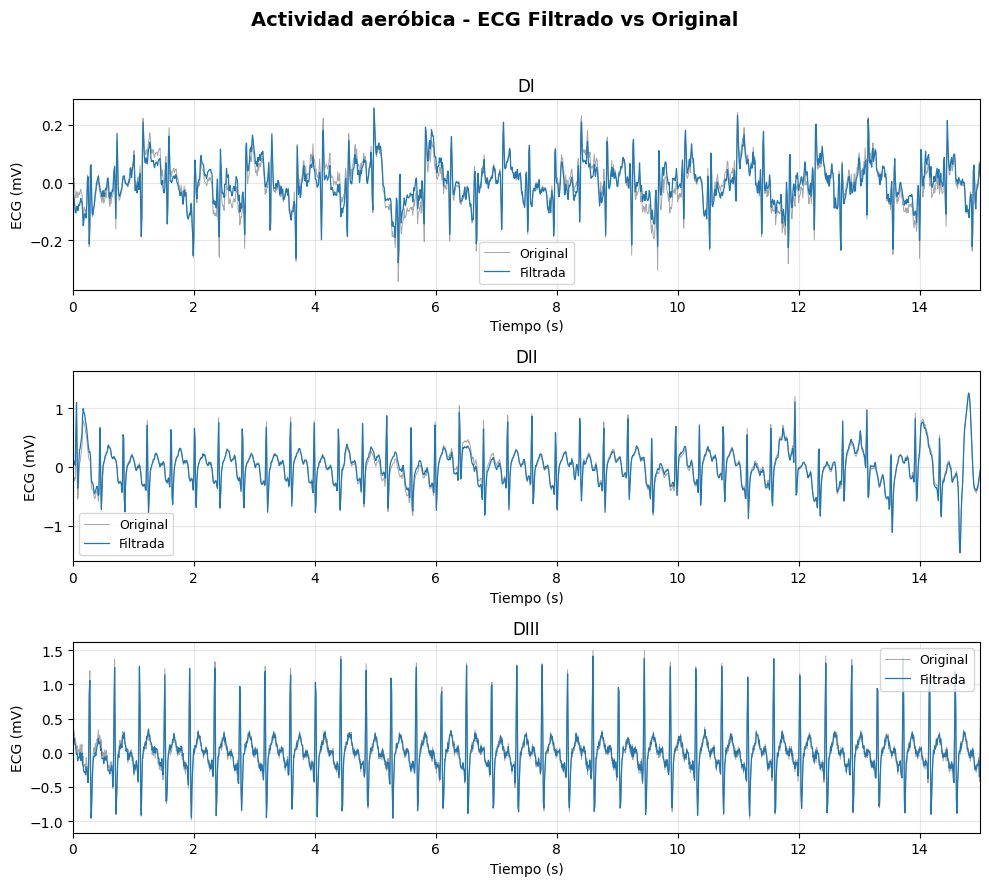

In [ ]:
import re
import matplotlib.pyplot as plt

for nombre_grupo, list_of_filenames in ARCHIVOS.items():
    print(f"\nCondición (filtrada): {nombre_grupo} ({len(list_of_filenames)} derivación(es))")
    # Convert the set of filenames into a dictionary mapping lead names to filenames
    # This ensures proper iteration and extraction of lead information.
    processed_dict_leads = {}
    for filename in list_of_filenames:
        # Attempt to extract lead identifier (e.g., 'DI', 'DII', 'DIII') from filename
        match = re.search(r'(D[I]+)\.txt', filename, re.IGNORECASE)
        if match:
            lead_identifier = match.group(1).upper()
            processed_dict_leads[lead_identifier] = filename
        else:
            # Fallback for filenames without a clear lead identifier
            # Use the filename without extension as the key
            processed_dict_leads[filename.replace('.txt', '')] = filename

    if not processed_dict_leads: # Handle cases where no valid files were processed for a group
        print(f"  [!] No se encontraron archivos válidos para el grupo {nombre_grupo} para filtrar.")
        plt.close() # Close any pending plot figures
        continue

    # Call the new grouped plotting function for filtered signals
    graficar_grupo_filtrado(nombre_grupo, processed_dict_leads, CANAL, CARPETA_DATOS,
                            notch_freq=49.5, carpeta_salida=CARPETA_SALIDA)
    plt.show()

## 7. Comparación general: las 4 condiciones, una figura por derivación

Como ahora hay 4 condiciones x 3 derivaciones (12 señales en total), en vez de meterlas todas en un solo gráfico se genera **una figura de comparación por cada derivación** (Lead I, Lead II, Lead III), superponiendo en cada una las 4 condiciones. El orden de capas (qué señal queda al frente) se controla con ZORDERS, definido en la celda de configuración.

  -> Figura de comparación general filtrada guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB4_ECG/figuras_bitalino/comparacion_general_filtrada_lead_i.png


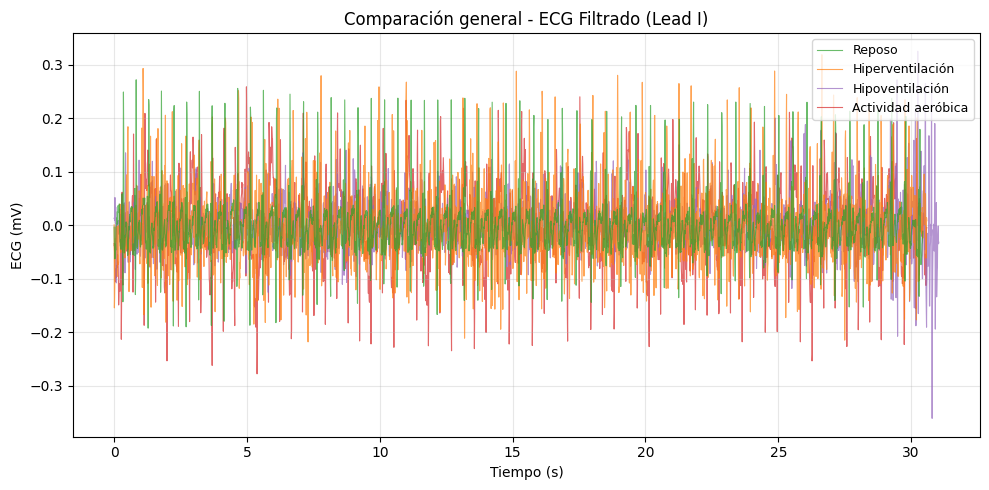

  -> Figura de comparación general filtrada guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB4_ECG/figuras_bitalino/comparacion_general_filtrada_lead_ii.png


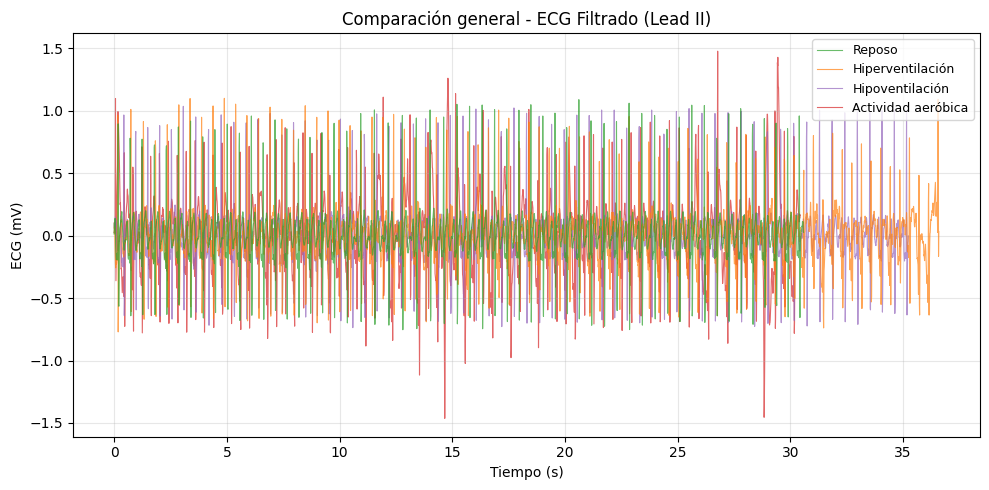

  -> Figura de comparación general filtrada guardada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB4_ECG/figuras_bitalino/comparacion_general_filtrada_lead_iii.png


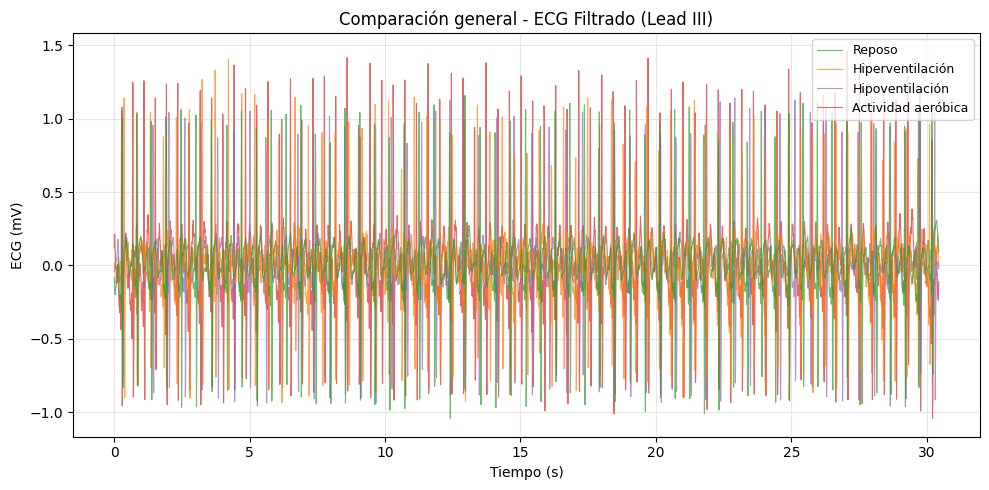

In [ ]:
for lead in ["Lead I", "Lead II", "Lead III"]:
    graficar_comparacion_por_lead(ARCHIVOS, lead, CANAL, CARPETA_DATOS,
                                   colores=COLORES, zorders=ZORDERS,
                                   carpeta_salida=CARPETA_SALIDA)
    plt.show()